In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
! pip install keras-tcn


--- Training TCN Model ---
Epoch 1/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 0.9629 - val_loss: 0.0295
Epoch 2/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 0.0269 - val_loss: 0.0128
Epoch 3/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 0.0119 - val_loss: 0.0067
Epoch 4/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 0.0080 - val_loss: 0.0054
Epoch 5/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - loss: 0.0058 - val_loss: 0.0072
Epoch 6/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 0.0045 - val_loss: 0.0050
Epoch 7/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 0.0037 - val_loss: 0.0023
Epoch 8/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 0.0034 - val_loss: 0.0044
Epoch 9/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 0.0027 - val_loss: 0.0044
Epoch 10/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 11/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 0.0023

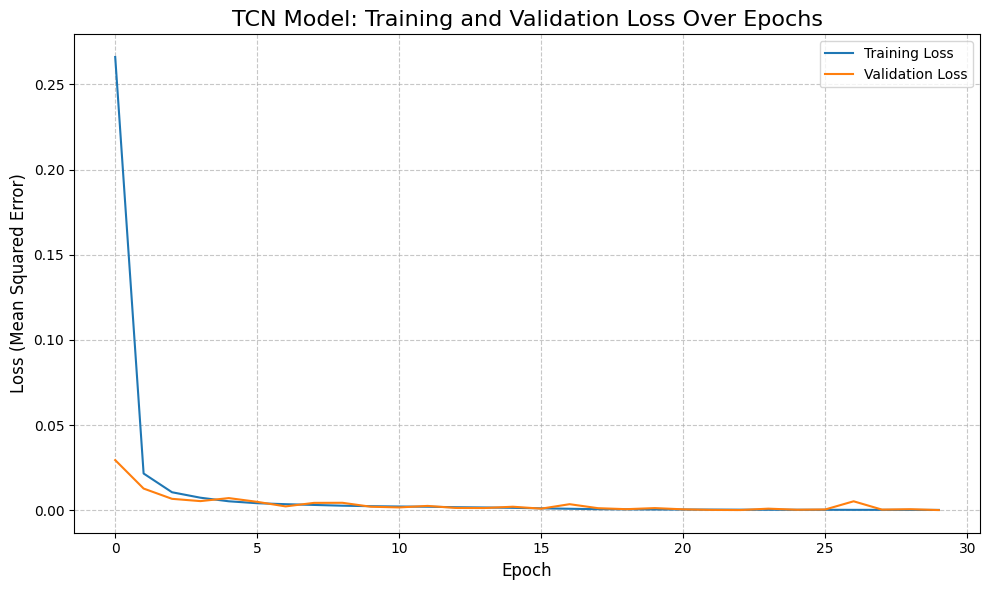

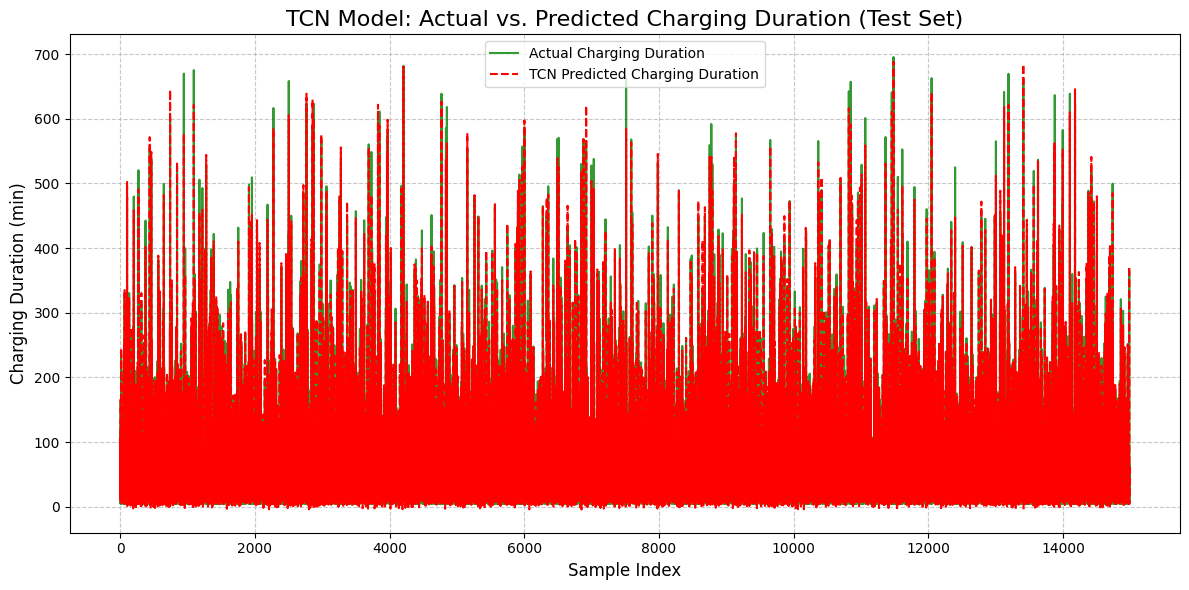

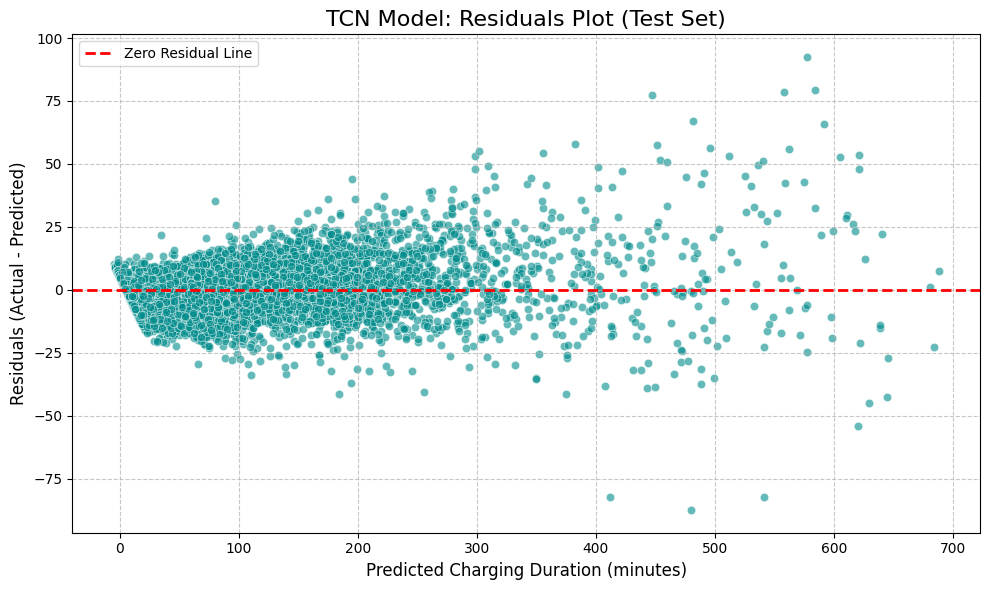

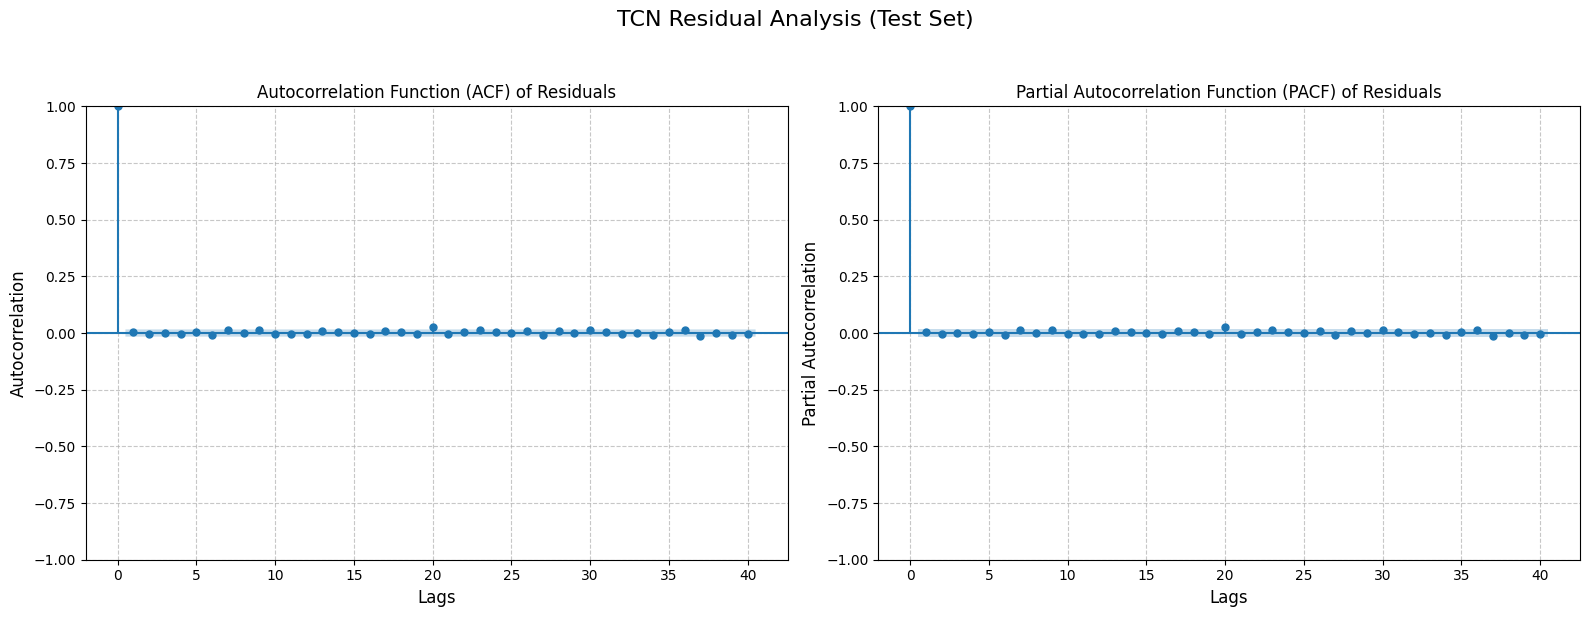


TCN model evaluation complete. Metrics printed and four plots generated.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import MeanSquaredError
from tcn import TCN # Import TCN layer
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # For residual analysis
import warnings

# Suppress UserWarning about input_shape and HDF5 saving for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


# --- 1. Load the Dataset ---
# Ensure X_train.csv, X_test.csv, y_train.csv, y_test.csv are accessible.
try:
    X_train = pd.read_csv(r"../data/X_train.csv")
    X_test = pd.read_csv(r"../data/X_test.csv")
    y_train = pd.read_csv(r"../data/y_train.csv")
    y_test = pd.read_csv(r"../data/y_test.csv")
except FileNotFoundError:
    print("Error: One or more data files (X_train.csv, X_test.csv, y_train.csv, y_test.csv) not found.")
    print("Please ensure your preprocessed and split data files are in the correct directory.")
    exit()

# --- 2. Scale features and target ---
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# --- 3. Reshape data for TCN (samples, timesteps, features) ---
# As per your notebook, timesteps=1.
# For true sequence modeling over multiple past observations, timesteps would be > 1.
X_train_tcn = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_tcn = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# --- 4. Build TCN model ---
model = Sequential()
# TCN layer with parameters from your notebook
model.add(TCN(input_shape=(X_train_tcn.shape[1], X_train_tcn.shape[2]),
              return_sequences=False,
              nb_filters=64,
              kernel_size=2,
              dilations=[1, 2, 4, 8], # Key for capturing long-term dependencies
              activation='relu',
              use_batch_norm=True))
model.add(Dense(1)) # Output layer for regression (single continuous value)
model.compile(optimizer='adam', loss=MeanSquaredError()) # Using MeanSquaredError object for clarity

# --- 5. Train the model ---
print("--- Training TCN Model ---")
# validation_split reserves a portion of training data for validation during training
history = model.fit(X_train_tcn, y_train_scaled, epochs=30, batch_size=32, validation_split=0.1, verbose=1)
print("TCN model training complete.")

# --- 6. Make Predictions for Training and Test Sets ---
# Predictions on training data (in-sample predictions)
y_train_pred_scaled_tcn = model.predict(X_train_tcn)
y_train_pred_tcn = scaler_y.inverse_transform(y_train_pred_scaled_tcn)
y_train_inv = scaler_y.inverse_transform(y_train_scaled) # Original scale of training target

# Predictions on test data (out-of-sample forecasts)
y_test_pred_scaled_tcn = model.predict(X_test_tcn)
y_test_pred_tcn = scaler_y.inverse_transform(y_test_pred_scaled_tcn)
y_test_inv = scaler_y.inverse_transform(y_test_scaled) # Original scale of test target

# --- 7. Evaluate the Model for Training and Test Sets ---
print("\n--- TCN Model Performance ---")

# Evaluate Training Set
train_mae = mean_absolute_error(y_train_inv, y_train_pred_tcn)
train_rmse = np.sqrt(mean_squared_error(y_train_inv, y_train_pred_tcn))
train_r2 = r2_score(y_train_inv, y_train_pred_tcn)
print("Model performance for Training set")
print(f"- Root Mean Squared Error (RMSE): {train_rmse:.4f}")
print(f"- Mean Absolute Error (MAE): {train_mae:.4f}")
print(f"- R2 Score: {train_r2:.4f}")
print('----------------------------------')

# Evaluate Test Set
test_mae = mean_absolute_error(y_test_inv, y_test_pred_tcn)
test_rmse = np.sqrt(mean_squared_error(y_test_inv, y_test_pred_tcn))
test_r2 = r2_score(y_test_inv, y_test_pred_tcn)
print("Model performance for Test set")
print(f"- Root Mean Squared Error (RMSE): {test_rmse:.4f}")
print(f"- Mean Absolute Error (MAE): {test_mae:.4f}")
print(f"- R2 Score: {test_r2:.4f}")
print('='*35)


# --- 8. Plot 1: Training and Validation Loss ---
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('TCN Model: Training and Validation Loss Over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- 9. Plot 2: Actual vs. Predicted Charging Duration (Test Set) ---
plt.figure(figsize=(12, 6))
# Plot actual test data
plt.plot(y_test_inv, label='Actual Charging Duration', color='green', alpha=0.8)
# Plot TCN predictions
plt.plot(y_test_pred_tcn, label='TCN Predicted Charging Duration', color='red', linestyle='--')
plt.title('TCN Model: Actual vs. Predicted Charging Duration (Test Set)', fontsize=16)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Charging Duration (min)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- 10. Plot 3: Residuals Plot (Test Set) ---
# Residuals = Actual Values - Predicted Values
residuals_tcn = y_test_inv - y_test_pred_tcn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_pred_tcn.flatten(), y=residuals_tcn.flatten(), alpha=0.6, color='darkcyan')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Residual Line')
plt.title('TCN Model: Residuals Plot (Test Set)', fontsize=16)
plt.xlabel('Predicted Charging Duration (minutes)', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# --- 11. Plot 4: ACF and PACF of Residuals (Test Set) ---
# Ensure residuals are a pandas Series for plotting
residuals_tcn_series = pd.Series(residuals_tcn.flatten())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_acf(residuals_tcn_series, ax=axes[0], lags=40, title='Autocorrelation Function (ACF) of Residuals')
axes[0].set_xlabel('Lags', fontsize=12)
axes[0].set_ylabel('Autocorrelation', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)

plot_pacf(residuals_tcn_series, ax=axes[1], lags=40, title='Partial Autocorrelation Function (PACF) of Residuals')
axes[1].set_xlabel('Lags', fontsize=12)
axes[1].set_ylabel('Partial Autocorrelation', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.suptitle('TCN Residual Analysis (Test Set)', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

print("\nTCN model evaluation complete. Metrics printed and four plots generated.")



In [4]:
X_train = pd.read_csv(r"../data/X_train.csv")
X_test = pd.read_csv(r"../data/X_test.csv")
y_train = pd.read_csv(r"../data/y_train.csv")
y_test = pd.read_csv(r"../data/y_test.csv")

In [5]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((59954, 92), (59954, 1), (14989, 92), (14989, 1))

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - loss: 0.0296 - val_loss: 0.0032
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0027 - val_loss: 0.0022
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.0015 - val_loss: 0.0030
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 9.7921e-04 - val_loss: 0.0020
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 8.9310e-04 - val_loss: 0.0020
Epoch 9/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 7.8549e-04 - val_loss: 0.0015
Epoch 10/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 7.1641e-04 - val_loss: 0.0015
Epoch 11/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 6.2891e-04 - val_loss: 0.0015
Epoch 12/30
422/422

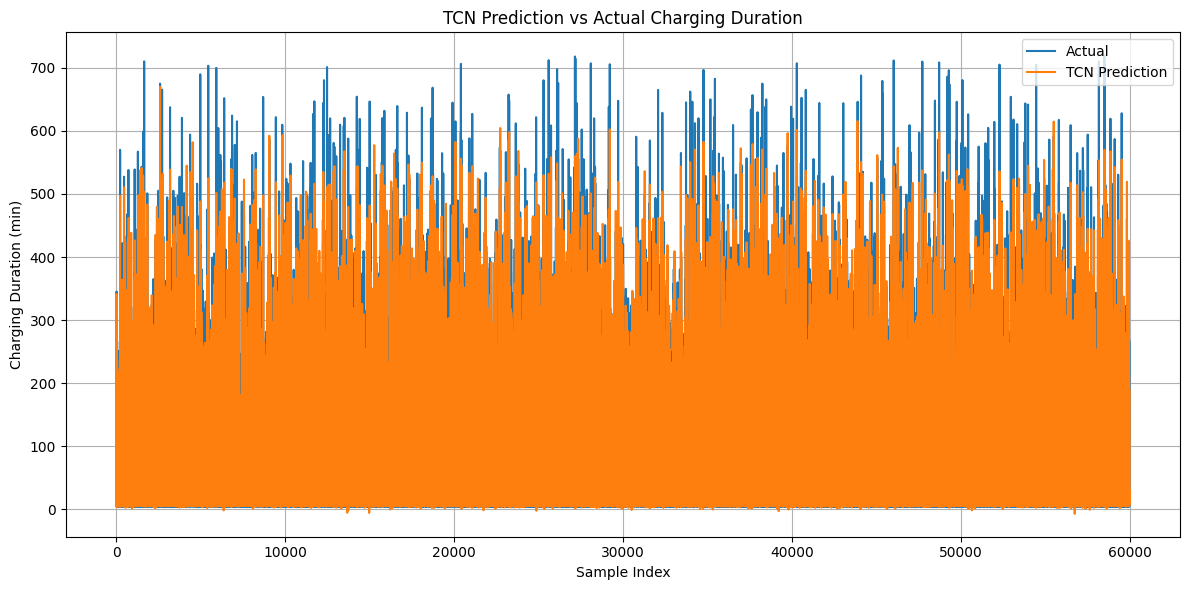

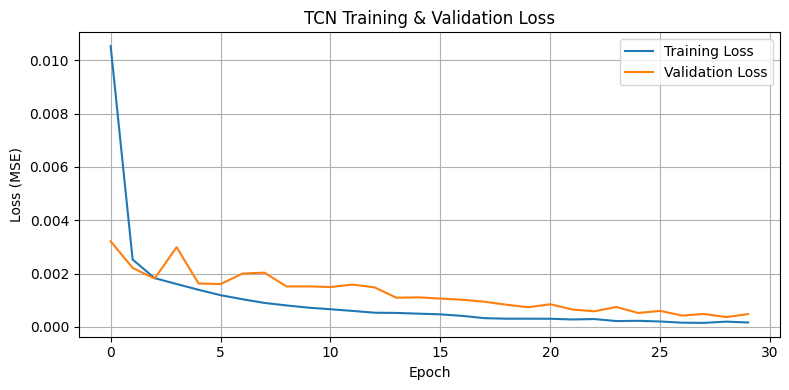

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tcn import TCN  # Install with `pip install keras-tcn`

# === Load data ===
X_test = pd.read_csv(r"../data/X_train.csv")
X_train = pd.read_csv(r"../data/X_test.csv")
y_test = pd.read_csv(r"../data/y_train.csv")
y_train = pd.read_csv(r"../data/y_test.csv")

# === Scale features ===
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# === Reshape for TCN (samples, timesteps, features) ===
X_train_tcn = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_tcn = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# === Build TCN model ===
model_tcn = Sequential()
model_tcn.add(TCN(input_shape=(X_train_tcn.shape[1], X_train_tcn.shape[2])))
model_tcn.add(Dense(1))
model_tcn.compile(optimizer='adam', loss='mse')

# === Train model ===
history_tcn = model_tcn.fit(X_train_tcn, y_train_scaled, epochs=30, batch_size=32, validation_split=0.1, verbose=1)

# === Predict and inverse scale ===
y_pred_tcn_scaled = model_tcn.predict(X_test_tcn)
y_pred_tcn = scaler_y.inverse_transform(y_pred_tcn_scaled)
y_test_inv = scaler_y.inverse_transform(y_test_scaled)

# === Evaluate ===
mse_tcn = mean_squared_error(y_test_inv, y_pred_tcn)
mae_tcn = mean_absolute_error(y_test_inv, y_pred_tcn)
r2_tcn = r2_score(y_test_inv, y_pred_tcn)

print("\n--- TCN Model Performance ---")
print(f"MSE: {mse_tcn:.2f}")
print(f"MAE: {mae_tcn:.2f}")
print(f"R² Score: {r2_tcn:.2f}")

# === Plot Actual vs Predicted ===
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_tcn, label='TCN Prediction')
plt.legend()
plt.xlabel('Sample Index')
plt.ylabel('Charging Duration (min)')
plt.title('TCN Prediction vs Actual Charging Duration')
plt.grid(True)
plt.tight_layout()
plt.show()

# === Plot Training Loss ===
plt.figure(figsize=(8,4))
plt.plot(history_tcn.history['loss'], label='Training Loss')
plt.plot(history_tcn.history['val_loss'], label='Validation Loss')
plt.title("TCN Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Epoch 1/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 57s 29ms/step - loss: 0.0230 - val_loss: 0.0020
Epoch 2/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 3/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 38s 23ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 4/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 37s 22ms/step - loss: 0.0010 - val_loss: 7.5201e-04
Epoch 5/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - loss: 6.4728e-04 - val_loss: 4.1266e-04
Epoch 6/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 1763s 1s/step - loss: 3.9664e-04 - val_loss: 2.3825e-04
Epoch 7/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - loss: 2.7277e-04 - val_loss: 1.7690e-04
Epoch 8/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - loss: 1.8308e-04 - val_loss: 6.3165e-04
Epoch 9/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - loss: 1.8266e-04 - val_loss: 2.8986e-04
Epoch 10/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - loss: 1.6283e-04 - val_loss: 4.0319e-04
Epoch 11/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 48s 

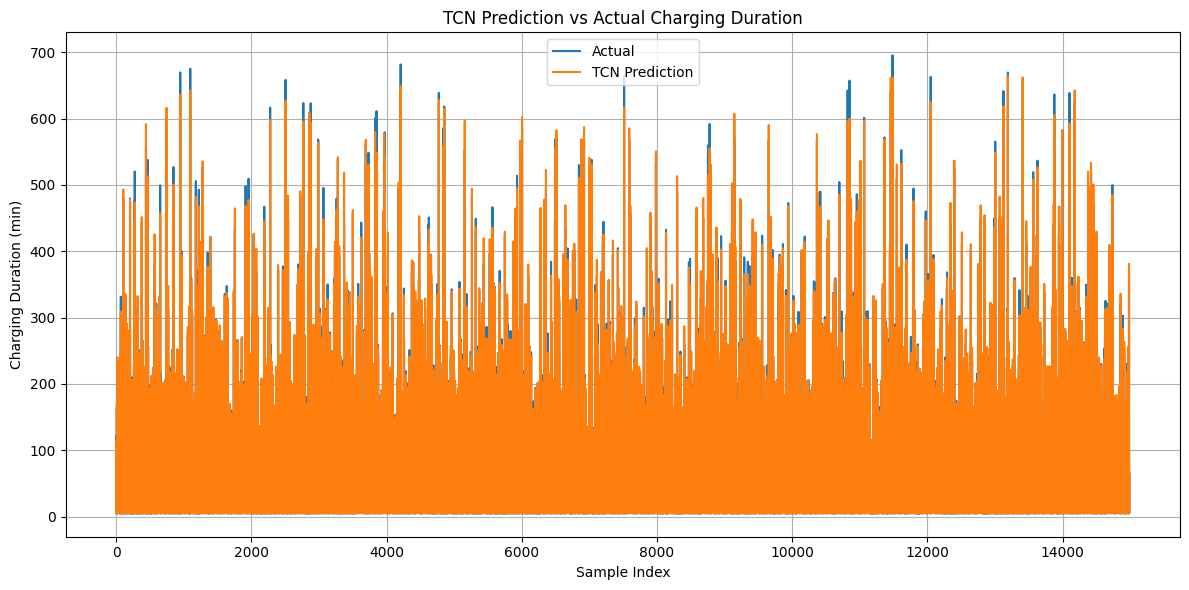

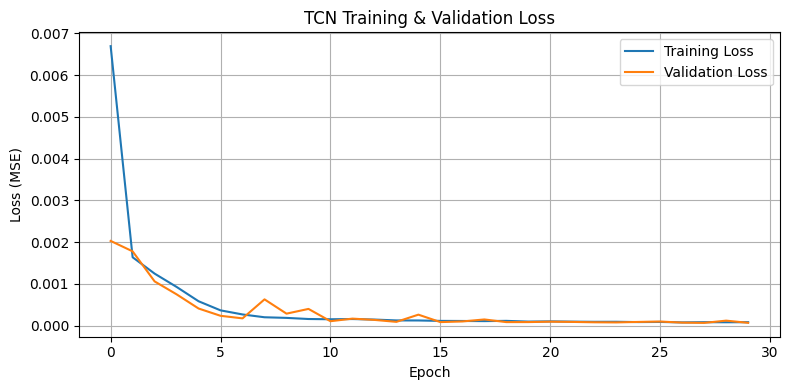

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tcn import TCN  # Install with `pip install keras-tcn`

# === Load data ===
X_train= pd.read_csv(r"../data/X_train.csv")
X_test = pd.read_csv(r"../data/X_test.csv")
y_train = pd.read_csv(r"../data/y_train.csv")
y_test = pd.read_csv(r"../data/y_test.csv")

# === Scale features ===
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# === Reshape for TCN (samples, timesteps, features) ===
X_train_tcn = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_tcn = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# === Build TCN model ===
model_tcn = Sequential()
model_tcn.add(TCN(input_shape=(X_train_tcn.shape[1], X_train_tcn.shape[2])))
model_tcn.add(Dense(1))
model_tcn.compile(optimizer='adam', loss='mse')

# === Train model ===
history_tcn = model_tcn.fit(X_train_tcn, y_train_scaled, epochs=30, batch_size=32, validation_split=0.1, verbose=1)

# === Predict and inverse scale ===
y_pred_tcn_scaled = model_tcn.predict(X_test_tcn)
y_pred_tcn = scaler_y.inverse_transform(y_pred_tcn_scaled)
y_test_inv = scaler_y.inverse_transform(y_test_scaled)

# === Evaluate ===
mse_tcn = mean_squared_error(y_test_inv, y_pred_tcn)
mae_tcn = mean_absolute_error(y_test_inv, y_pred_tcn)
r2_tcn = r2_score(y_test_inv, y_pred_tcn)

print("\n--- TCN Model Performance ---")
print(f"MSE: {mse_tcn:.2f}")
print(f"MAE: {mae_tcn:.2f}")
print(f"R² Score: {r2_tcn:.2f}")

# === Plot Actual vs Predicted ===
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_tcn, label='TCN Prediction')
plt.legend()
plt.xlabel('Sample Index')
plt.ylabel('Charging Duration (min)')
plt.title('TCN Prediction vs Actual Charging Duration')
plt.grid(True)
plt.tight_layout()
plt.show()

# === Plot Training Loss ===
plt.figure(figsize=(8,4))
plt.plot(history_tcn.history['loss'], label='Training Loss')
plt.plot(history_tcn.history['val_loss'], label='Validation Loss')
plt.title("TCN Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
import os

# Define the relative path to the saving folder
save_dir = "../Saving The Model Results"
model_filename = "tcn_charging_duration_model.h5"
model_path = os.path.join(save_dir, model_filename)

# Create the folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Save the model
model_tcn.save(model_path)

print(f"Model saved at: {model_path}")


Model saved at: ../Saving The Model Results\tcn_charging_duration_model.h5
